# Session 4: Convolutional Neural Networks and Filters

This notebook contains structured tasks based on Session 4 materials.

**Instructions:**
- Do NOT use a separate `.py` file. Complete all tasks directly in this notebook.
- Keep your code clear and well-commented.
- For Visulaization, please use `%matplotlib inline`
- Submit your completed notebook by uploading it to your forked repository.

### ***DO NOT UPLOAD THE DATASET TO GITHUB as it's too large***
<hr>

## Task 1: Convolutional Filters on an Image
Apply several 2D filters (Sobel X, Sobel Y, Laplacian, and Sharpen) to an image and visualize the results side by side.

**Hint:**
- Use OpenCV (`cv2.filter2D`) or NumPy to apply kernels.
- Define common kernels (Sobel, Laplacian, Sharpen).
- Use `matplotlib.pyplot` to plot the original and filtered images.

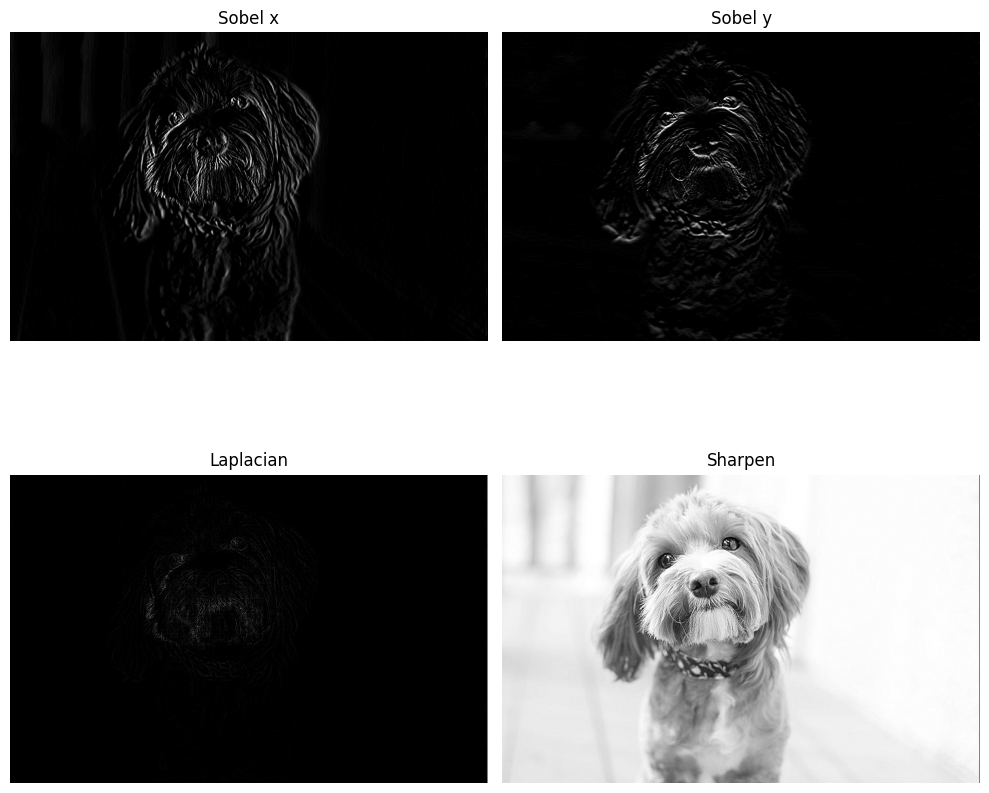

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
# TODO: Load an image (use OpenCV or matplotlib)
img=cv.imread('images/dogone.jpeg')
# TODO: Convert to grayscale
gray_img=cv.cvtColor(img,cv.COLOR_BGR2GRAY)
cv.imshow('gray',gray_img)
cv.waitKey()
cv.destroyAllWindows()
# TODO: Define Sobel, Laplacian, and Sharpen kernels
# sobel=cv.Sobel(img,cv.CV_64F,1,0, ksize=3)
# laplacian=cv.Laplacian(img, cv.CV_64F)
#THE KERNALS 
sobel_x=np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]])
sobel_y=np.array([[-1, -2, -1],[ 0,  0,  0],[ 1,  2,  1]])
laplacian=np.array([[0,  1, 0],[1, -4, 1],[0,  1, 0]])
sharpen=np.array([[0, -1, 0],[-1, 5, -1], [0, -1, 0]])
# TODO: Apply each filter to the image
xsobel_img=cv.filter2D(gray_img,-1,sobel_x)
ysobel_img=cv.filter2D(gray_img,-1,sobel_y)
laplacian_img=cv.filter2D(gray_img,-1,laplacian)
sharpen_img=cv.filter2D(gray_img,-1,sharpen)
# TODO: Plot results in a grid using matplotlib
plt.figure(figsize=(10, 10))
plt.subplot(2,2,1),plt.imshow(xsobel_img,cmap='gray'),plt.title('Sobel x'),plt.axis('off')
plt.subplot(2,2,2),plt.imshow(ysobel_img,cmap='gray'),plt.title('Sobel y'),plt.axis('off')
plt.subplot(2,2,3),plt.imshow(laplacian_img,cmap='gray'),plt.title('Laplacian'),plt.axis('off')
plt.subplot(2,2,4),plt.imshow(sharpen_img,cmap='gray'),plt.title('Sharpen'),plt.axis('off')
plt.tight_layout()
plt.show()


## Task 2: Build a Simple CNN on FashionMNIST
Construct and train a small Convolutional Neural Network (CNN) on the FashionMNIST dataset.

**Hint:**
- Use `torchvision.datasets.FashionMNIST` for loading data.
- Define a small CNN with `nn.Conv2d`, `nn.ReLU`, `nn.MaxPool2d`, and `nn.Linear`.
- Train for a few epochs using an optimizer (e.g., Adam) and loss function (e.g., CrossEntropyLoss).
- Print training accuracy after each epoch.

In [ ]:
# TODO: Import torch, torchvision, and related libraries
import torch
import torchvision
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader
from torchvision import transforms
from collections import OrderedDict
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
# TODO: Load FashionMNIST dataset with transforms
data_transform=transforms.ToTensor()
train_data=FashionMNIST(root='./data',train=True,
                                   download=True,transform=data_transform)
test_data=FashionMNIST(root='./data',train=False,
                                  download=True,transform=data_transform)
batch_size=10
train_loader=DataLoader(train_data,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(test_data,batch_size=batch_size,shuffle=True)
classes=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
# TODO: Define a simple CNN class with one conv layer and one fc layer
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.layer1 = nn.Sequential(
            OrderedDict([
                ('conv1',nn.Conv2d(1,5,kernel_size=3)),
                ('relu1',nn.ReLU()),
                ('bachnorm1', nn.BatchNorm2d(5)) 
            ])
        )
        self.fc1=nn.Linear(5*26*26,10)
    def forward(self, x):
        out=self.layer1(x)
        out=out.view(out.size(0),-1)  
        out=self.fc1(out)
        return F.log_softmax(out, dim=1)
net=Net()
print(net)
# TODO: Set up optimizer and loss function
criterion=nn.NLLLoss()
optimizer=optim.Adam(net.parameters()) 
correct=0
total=0
for images,labels in test_loader:
    outputs=net(images)
    _, predicted=torch.max(outputs.data,1)
    total+=labels.size(0)
    correct+=(predicted == labels).sum()
accuracy=100*correct.item()/total
print('Accuracy before training:', accuracy)
# TODO: Implement a short training loop (2-3 epochs)
n_epochs=3
def train(n_epochs):
    for epoch in range(n_epochs):
        running_loss=0.0
        for batch_i,data in enumerate(train_loader):
            inputs,labels=data       
            optimizer.zero_grad()
            outputs=net(inputs)
            loss=criterion(outputs,labels)
            loss.backward()
            optimizer.step()
            running_loss+=loss.item()
            if batch_i%1000==999:
                print('Epoch: {}, Batch: {}, Avg. Loss: {}'.format(epoch + 1, batch_i+1, running_loss/1000))

100.0%
100.0%
100.0%
100.0%


Net(
  (layer1): Sequential(
    (conv1): Conv2d(1, 5, kernel_size=(3, 3), stride=(1, 1))
    (relu1): ReLU()
    (bachnorm1): BatchNorm2d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (fc1): Linear(in_features=3380, out_features=10, bias=True)
)
Accuracy before training: 13.4


## Task 3: Visualize Feature Maps
Visualize feature maps produced by the first convolutional layer of your CNN.

**Hint:**
- Take a single image from the test set.
- Pass it through the first convolutional layer (`net.conv1`).
- Convert the output to NumPy and plot several channels as images.

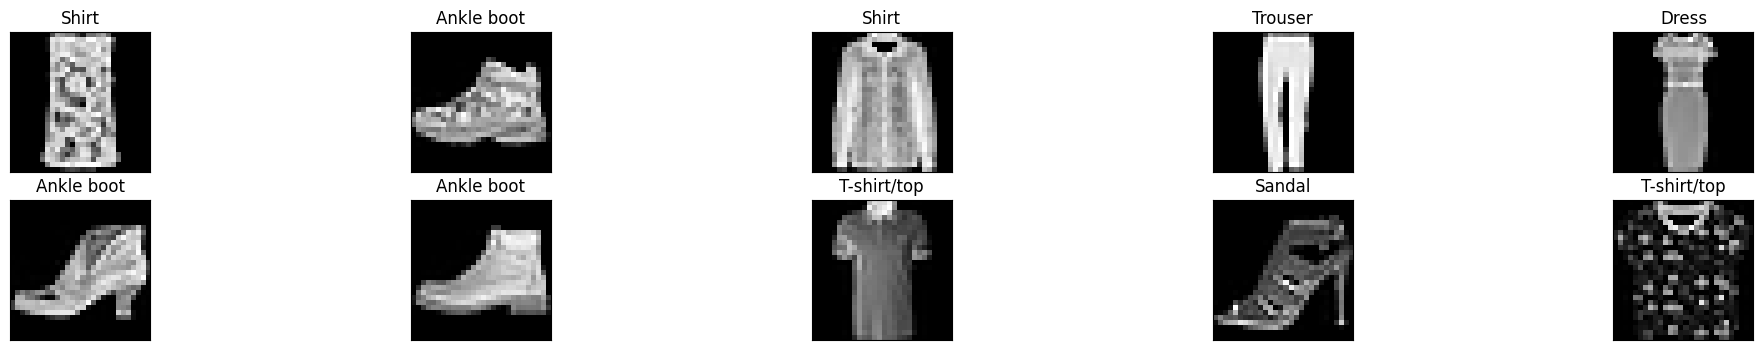

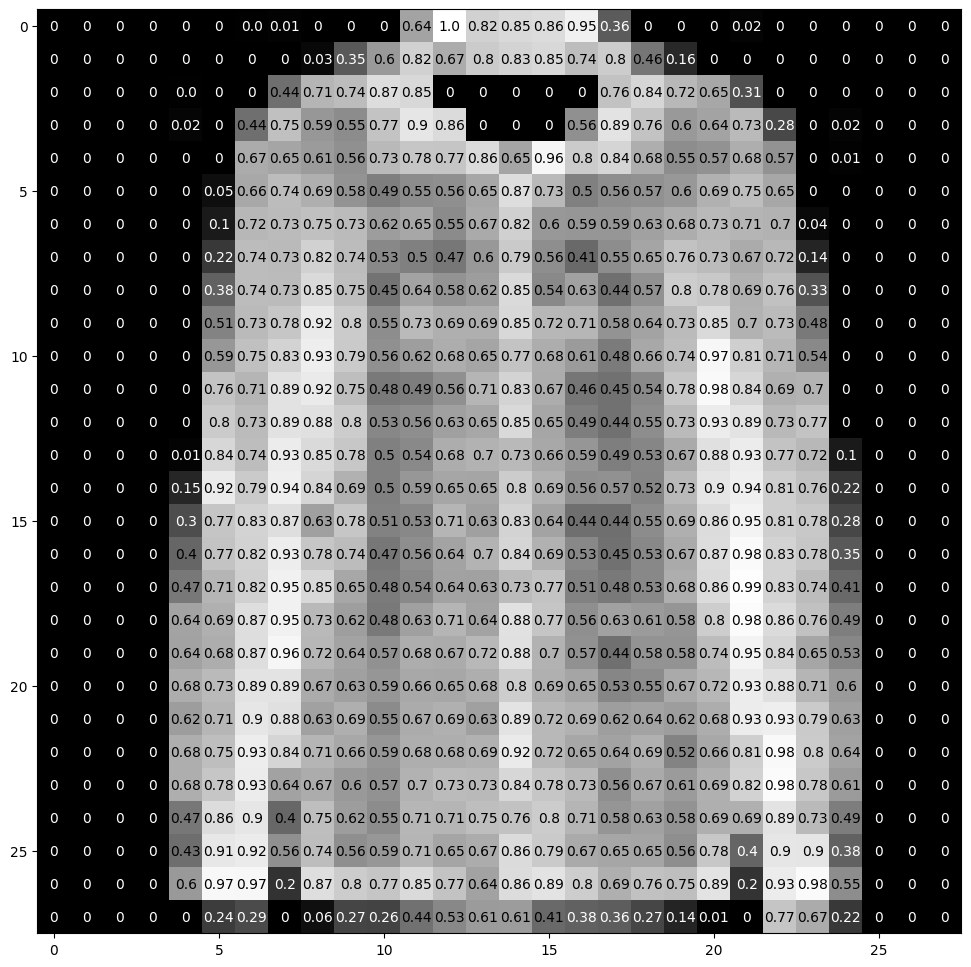

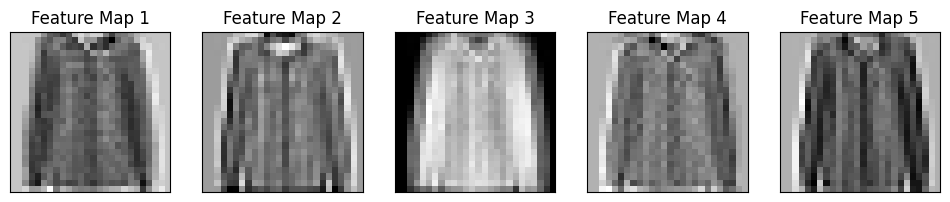

In [ ]:
# TODO: Take one test image
dataiter=iter(train_loader)
images,labels=next(dataiter)
images=images.numpy()
fig=plt.figure(figsize=(25,4))
for idx in np.arange(batch_size):
    ax=fig.add_subplot(2, batch_size//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title(classes[labels[idx]])
idx=2
img=np.squeeze(images[idx])
fig=plt.figure(figsize=(12,12)) 
ax=fig.add_subplot(111)
ax.imshow(img,cmap='gray')
width,height=img.shape
thresh =img.max()/2.5
for x in range(width):
    for y in range(height):
        val=round(img[x][y],2) if img[x][y] !=0 else 0
        ax.annotate(str(val),xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center',
                    color='white' if img[x][y]<thresh else 'black')
# TODO: Forward pass through the first convolutional layer
img_tensor=torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float()
with torch.no_grad():
    feature_maps=net.layer1[0](img_tensor)
# TODO: Convert feature maps to NumPy array
feature_maps=feature_maps.squeeze().numpy()
# TODO: Plot the first few feature maps in a grid
fig = plt.figure(figsize=(12,6))
for i in range(feature_maps.shape[0]):
    ax=fig.add_subplot(1,feature_maps.shape[0],i+1,xticks=[],yticks=[])
    ax.imshow(feature_maps[i],cmap='gray')
    ax.set_title(f'Feature Map {i+1}')
plt.show()

## Task 4: Haar Cascade Face Detection

Apply Haar Cascade classifiers for basic object detection (faces).

**Hint:**
- Use `cv2.CascadeClassifier` with a pre-trained XML file (e.g., `haarcascade_frontalface_default.xml`).
- Convert the input image to grayscale before detection.
- Use `detectMultiScale` to get bounding boxes.
- Draw rectangles on detected faces with `cv2.rectangle`.
- Visualize with Matplotlib.


We found 2 faces in this image
Their coordinates and lengths/widths are as follows
[[ 880 4169   80   80]
 [ 458 1170 2408 2408]]


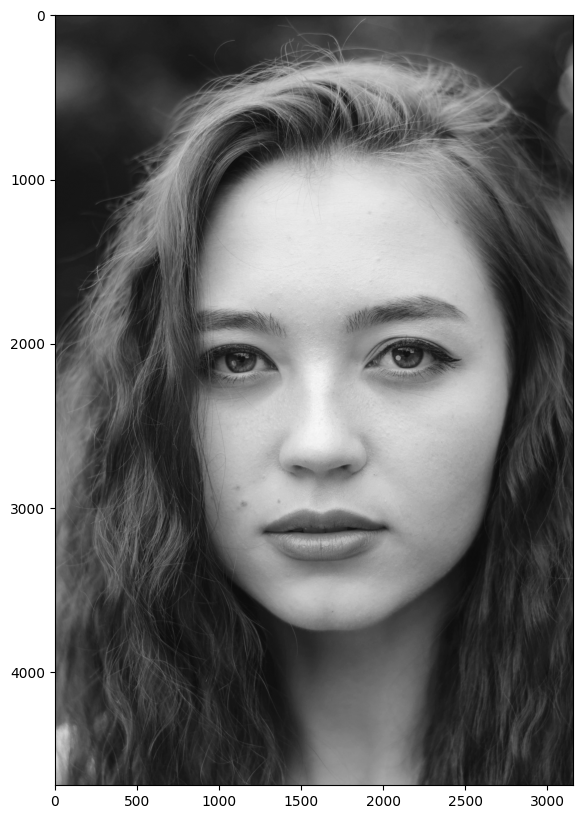

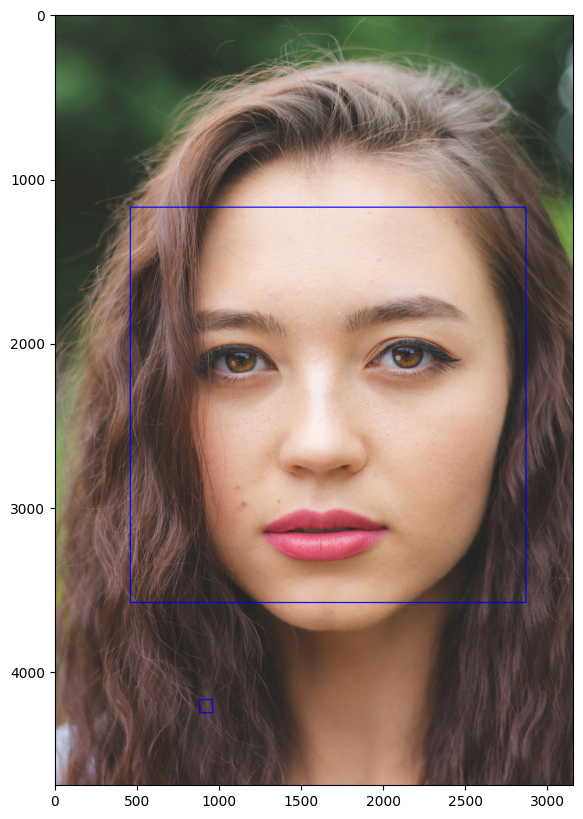

In [ ]:
# TODO: Load an image containing a face
img=cv.imread('images/face.jpg')
# TODO: Convert to grayscale
gray=cv.cvtColor(img,cv.COLOR_BGR2GRAY)
plt.figure(figsize=(20,10))
plt.imshow(gray,cmap='gray')
# TODO: Load Haar Cascade XML (frontal face) || cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
face_cascade=cv.CascadeClassifier(cv.data.haarcascades+'haarcascade_frontalface_default.xml')
# TODO: Apply detectMultiScale to find faces
faces = face_cascade.detectMultiScale(gray, 1.1, 5)
print('We found ' + str(len(faces)) + ' faces in this image')
print("Their coordinates and lengths/widths are as follows")
print('=============================')
print(faces)
# TODO: Draw bounding boxes on the original image
img_with_detections=np.copy(img) 
for (x,y,w,h) in faces:
    cv.rectangle(img_with_detections,(x, y),(x+w, y+h),(255,0,0),5)  
# TODO: Display results with matplotlib
plt.figure(figsize=(20,10))
plt.imshow(cv.cvtColor(img_with_detections, cv.COLOR_BGR2RGB)) 
## the output said two faces and it is only one i dunno why that 